# Knowledge Representation and Reasoning
## AIAT 111 - Unit 1: Introduction to AI and Applications

---

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand knowledge representation theory in AI
- Learn about different knowledge models and representation methods
- Understand the structure of knowledge-based agents
- Implement simple knowledge representation systems
- Work with facts and rule-based systems (knowledge graphs arrive in Unit 2's RDF/SPARQL notebook)

---

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 04 "Intelligent Agents and Rationality" — a knowledge-based agent is an agent whose percepts are stored as facts and rules.

**Used later in:** Course 02 (AIAT 112) — Unit 2, which builds full rule engines, knowledge graphs and first-order logic on this foundation.

---


## 🎯 Forty years of typing in what everybody already knows

In **1984** Doug Lenat started **Cyc** at MCC in Austin, Texas, on a bet: that the
reason programs were brittle was that nobody had ever written down common sense,
and that a team could simply *encode* it — that a person who is wet has been in
water, that you cannot be in two places at once, that a dead person stays dead.
Cyc has been under construction ever since, with millions of hand-authored
assertions. It is simultaneously the field's most ambitious knowledge-representation
project and its most-cited cautionary tale about how expensive hand-built knowledge is.

Compare **Google's Knowledge Graph**, launched in May 2012 under the slogan
"things, not strings". Instead of hand-encoding common sense, Google built a graph
of entities and relations harvested at scale, and used it to answer questions like
"how tall is the Eiffel Tower" directly rather than returning ten blue links. Same
core idea — facts and relations a machine can traverse — opposite bet on where the
facts come from. That tension, **authored versus harvested**, is still the central
question in this area, and you will meet it again as knowledge graphs are used to
ground language models.

### What goes wrong without explicit knowledge

Without a knowledge base, everything a program "knows" is buried in its control
flow. Change a policy and you go hunting for the `if` statements that encoded it.
The agent below does the opposite: it **TELLs** facts into a store and **ASKs**
queries against it, so what the system believes is a piece of data you can print,
audit, correct and hand to a domain expert who cannot read Python. That separation
— knowledge apart from the code that uses it — is the entire point of this lesson.


## 1. Introduction to Knowledge Representation

Knowledge representation is a fundamental aspect of AI that deals with how to store and organize information in a way that AI systems can use it for reasoning and decision-making.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Knowledge Representation Concepts

# Knowledge is information that enables an agent to act intelligently
# Knowledge representation is about how to encode this information

class KnowledgeBase:
    """
    Simple knowledge base structure
    """
    def __init__(self):
        self.facts = []  # Simple facts storage
        self.rules = []  # If-then rules
        
    def add_fact(self, fact):
        """Add a fact to the knowledge base"""
        self.facts.append(fact)
        
    def add_rule(self, condition, conclusion):
        """Add a rule: if condition then conclusion"""
        self.rules.append({'if': condition, 'then': conclusion})
        
    def query(self, question):
        """Query the knowledge base"""
        # Check if answer exists in facts
        for fact in self.facts:
            if question in fact:
                return fact
        return None

# Create a simple knowledge base
kb = KnowledgeBase()

# Add some facts
kb.add_fact("Python is a programming language")
kb.add_fact("AI uses Python for machine learning")
kb.add_fact("Knowledge representation is important in AI")

print("✅ Knowledge base created")
print(f"Facts stored: {len(kb.facts)}")


✅ Knowledge base created
Facts stored: 3


## 2. Knowledge Models and Representation

Different ways to represent knowledge:
- Facts and Rules
- Semantic Networks
- Frames and Scripts
- Ontologies


In [2]:
# Representing knowledge as facts and rules

# Example: Expert system for animal classification
animal_kb = KnowledgeBase()

# Facts
animal_kb.add_fact("Birds have feathers")
animal_kb.add_fact("Mammals have fur")
animal_kb.add_fact("Fish live in water")

# Rules
animal_kb.add_rule("has feathers", "is a bird")
animal_kb.add_rule("has fur", "is a mammal")
animal_kb.add_rule("lives in water", "is a fish")

def classify_animal(characteristics, kb):
    """Classify animal based on characteristics"""
    for rule in kb.rules:
        if rule['if'] in characteristics:
            return rule['then']
    return "unknown"

# Example classification
result = classify_animal("has feathers", animal_kb)
print(f"Classification result: {result}")


Classification result: is a bird


BEFORE — three rules, tried in the order they were added
  eagle   -> is a bird    (should be is a bird   ) ok 
  dog     -> is a mammal  (should be is a mammal ) ok 
  salmon  -> is a fish    (should be is a fish   ) ok 
  whale   -> is a fish    (should be is a mammal ) WRONG

AFTER — one rule inserted at the front of the SAME list, code untouched
  eagle   -> is a bird    (should be is a bird   ) ok 
  dog     -> is a mammal  (should be is a mammal ) ok 
  salmon  -> is a fish    (should be is a fish   ) ok 
  whale   -> is a mammal  (should be is a mammal ) ok 


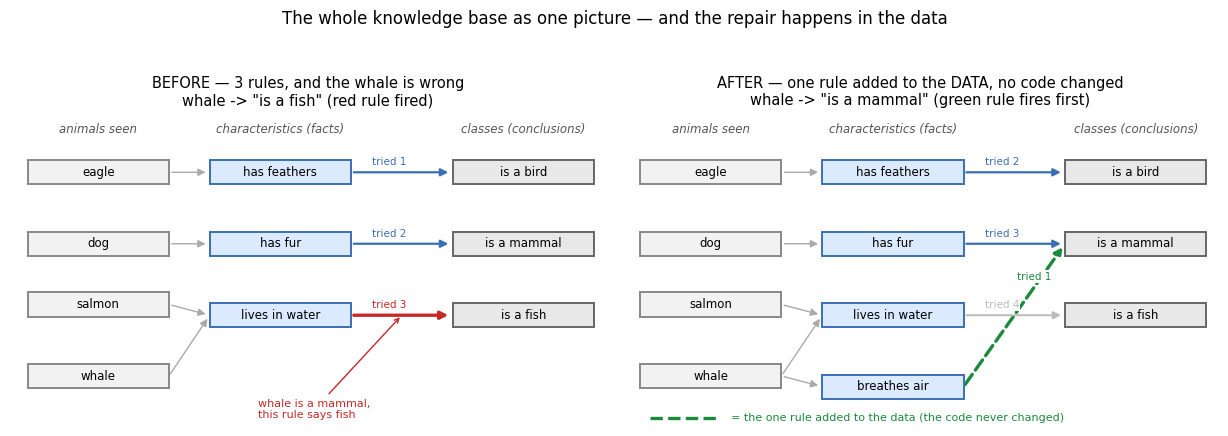

In [3]:
# ── Seeing the knowledge base ────────────────────────────────────────────────
# WHAT: draw every fact and every rule of `animal_kb` as one picture, then repair
#       a wrong answer by editing the DATA (adding a rule) and redraw.
# WHY : the lesson's whole claim is that knowledge lives outside the code. A base
#       you can look at is a base a domain expert can audit — that is the payoff.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# Four animals described the way a sensor or a form would describe them.
observed = {
    "eagle":  "has feathers and flies",
    "dog":    "has fur and barks",
    "salmon": "lives in water and has scales",
    "whale":  "lives in water and breathes air",
}
truth = {"eagle": "is a bird", "dog": "is a mammal",
         "salmon": "is a fish", "whale": "is a mammal"}

# Run the classifier we already wrote, with the three rules already in the base.
rules_before = [dict(r) for r in animal_kb.rules]
before = {a: classify_animal(c, animal_kb) for a, c in observed.items()}

print("BEFORE — three rules, tried in the order they were added")
for a in observed:
    mark = "ok " if before[a] == truth[a] else "WRONG"
    print(f"  {a:<7} -> {before[a]:<12} (should be {truth[a]:<12}) {mark}")

# THE REPAIR: no Python changes. We insert one more specific rule ahead of the
# general one, because `classify_animal` returns the FIRST rule that matches.
animal_kb.rules.insert(0, {"if": "breathes air", "then": "is a mammal"})
after = {a: classify_animal(c, animal_kb) for a, c in observed.items()}

print("\nAFTER — one rule inserted at the front of the SAME list, code untouched")
for a in observed:
    mark = "ok " if after[a] == truth[a] else "WRONG"
    print(f"  {a:<7} -> {after[a]:<12} (should be {truth[a]:<12}) {mark}")

# ── the picture ──────────────────────────────────────────────────────────────
CH = {"has feathers": 3.0, "has fur": 2.0, "lives in water": 1.0, "breathes air": 0.0}
CL = {"is a bird": 3.0, "is a mammal": 2.0, "is a fish": 1.0}
AN = {"eagle": 3.0, "dog": 2.0, "salmon": 1.15, "whale": 0.15}
ANIMAL_CH = {"eagle": ["has feathers"], "dog": ["has fur"],
             "salmon": ["lives in water"], "whale": ["lives in water", "breathes air"]}
XA, XC, XL = 0.0, 1.65, 3.85          # fixed columns: no random layout, ever

def _node(ax, x, y, text, fc, ec, w=1.28, h=0.34):
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, fc=fc, ec=ec, lw=1.4, zorder=3))
    ax.text(x, y, text, ha="center", va="center", fontsize=8.5, zorder=4)

def _arrow(ax, x0, y0, x1, y1, color, lw=1.2, ls="-"):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=11,
                                 color=color, lw=lw, linestyle=ls, zorder=2,
                                 shrinkA=2, shrinkB=3))

def _panel(ax, rules, title, show_breathes):
    ax.set_title(title, fontsize=10.5, pad=10)
    for a, y in AN.items():
        _node(ax, XA, y, a, "#f2f2f2", "#888888")
    for c, y in CH.items():
        if c == "breathes air" and not show_breathes:
            continue
        _node(ax, XC, y, c, "#dbeafe", "#3b6fb5")
    for k, y in CL.items():
        _node(ax, XL, y, k, "#e8e8e8", "#666666")
    for a, chs in ANIMAL_CH.items():                      # observation edges
        for c in chs:
            if c == "breathes air" and not show_breathes:
                continue
            _arrow(ax, XA + 0.64, AN[a], XC - 0.64, CH[c], "#aaaaaa", lw=1.0)
    for i, r in enumerate(rules):                          # rule edges, in trial order
        c, k = r["if"], r["then"]
        if c == "breathes air":
            col, lw, ls = "#1a8a3c", 2.4, "--"             # the rule we added
        elif c == "lives in water" and not show_breathes:
            col, lw, ls = "#c62828", 2.4, "-"              # the rule that misfires
        elif c == "lives in water":
            col, lw, ls = "#bbbbbb", 1.4, "-"              # now reached too late to misfire
        else:
            col, lw, ls = "#3b6fb5", 1.6, "-"
        _arrow(ax, XC + 0.64, CH[c], XL - 0.64, CL[k], col, lw=lw, ls=ls)
        t = 0.70 if c == "breathes air" else 0.38          # slide labels apart
        lx = (XC + 0.64) + t * ((XL - 0.64) - (XC + 0.64))
        ly = CH[c] + t * (CL[k] - CH[c])
        ax.text(lx, ly + 0.10, f"tried {i + 1}", ha="center", fontsize=7.5, color=col,
                bbox=dict(fc="white", ec="none", pad=0.8), zorder=5)
    ax.set_xlim(-0.80, 4.60); ax.set_ylim(-0.55, 3.75); ax.axis("off")
    for x, lab in [(XA, "animals seen"), (XC, "characteristics (facts)"),
                   (XL, "classes (conclusions)")]:
        ax.text(x, 3.55, lab, ha="center", fontsize=8.5, style="italic", color="#555555")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))
_panel(axes[0], rules_before,
       f"BEFORE — 3 rules, and the whale is wrong\nwhale -> \"{before['whale']}\" (red rule fired)",
       False)
axes[0].annotate("whale is a mammal,\nthis rule says fish",
                 xy=((XC + XL) / 2, (CH["lives in water"] + CL["is a fish"]) / 2),
                 xytext=(1.45, -0.44), fontsize=8, color="#c62828",
                 arrowprops=dict(arrowstyle="->", color="#c62828", lw=1.0))
_panel(axes[1], animal_kb.rules,
       f"AFTER — one rule added to the DATA, no code changed\nwhale -> \"{after['whale']}\" (green rule fires first)",
       True)
axes[1].plot([-0.55, 0.05], [-0.44, -0.44], color="#1a8a3c", lw=2.4, ls="--", clip_on=False)
axes[1].text(0.18, -0.44, "= the one rule added to the data (the code never changed)",
             fontsize=8, color="#1a8a3c", va="center")
fig.suptitle("The whole knowledge base as one picture — and the repair happens in the data",
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


### 👁️ Read the two panels

Both panels show **the same three columns**: the animals we observed, the
characteristics stored as facts, and the classes the rules conclude. The arrows
between the middle and right columns *are* the rules, labelled with the order
`classify_animal` tries them.

- **Left panel.** Four animals, three rules. Three answers are right. The **thick
  red arrow** is rule 3, `lives in water → is a fish`, and the whale reaches it
  first — so the base confidently answers `is a fish`. The printout above says
  `WRONG` next to that one line. Nothing in the code is broken; the *knowledge*
  is wrong, and you can point at the exact arrow that is wrong.
- **Right panel.** Identical layout, one thing added: the **green dashed arrow**,
  `breathes air → is a mammal`, inserted at the front of `animal_kb.rules`. Follow
  the whale: it still reaches `lives in water`, but that rule is now *tried 4* and
  the green *tried 1* gets there first. The whale line in the printout flips to
  `is a mammal`. The grey arrow on the right is the old fish rule, still present,
  now simply reached too late to do damage.

That is the claim of this lesson, made visible: **the bug was a row of data, and
the fix was a row of data.** No `if` statement was edited. Notice also what the
picture does *not* show — nothing on it says how certain any rule is, and an
animal with none of these characteristics would simply have no arrow leaving it.
Those two gaps are what Unit 2's Bayes notebook and RDF notebook pick up.


## 3. Knowledge-Based Agents

Knowledge-based agents use a knowledge base to store information and inference rules to derive new information.


In [4]:
# A knowledge-based agent: instead of hard-coding behavior, it TELLs facts into a
# knowledge base and ASKs queries against it — separating what the agent knows from how it acts.
class KnowledgeBasedAgent:
    """
    Simple knowledge-based agent structure
    """
    def __init__(self, knowledge_base):
        self.kb = knowledge_base
        
    def tell(self, sentence):
        """Add information to knowledge base"""
        self.kb.add_fact(sentence)
        
    def ask(self, query):
        """Query the knowledge base"""
        return self.kb.query(query)
        
    # Forward-chaining in miniature: fire the first rule whose IF-part matches the observation.
    def infer(self, observation):
        """Make inference based on observation and rules"""
        # Check rules for inference
        for rule in self.kb.rules:
            if rule['if'] in observation:
                return rule['then']
        return None

# Create agent with knowledge base
# Exercise the tell/ask cycle on the knowledge base built earlier in this notebook.
agent = KnowledgeBasedAgent(kb)

# Agent receives new information
agent.tell("Knowledge representation enables reasoning")

# Agent makes query
answer = agent.ask("Knowledge representation")
print(f"Agent's answer: {answer}")

Agent's answer: Knowledge representation is important in AI


## 💬 Discuss

The classifier above concluded `is a bird` from feathers and flight, and the
knowledge-based agent answered a question from three stored facts. Argue:

1. Our rule says feathers + flies → bird. **A penguin has feathers and does not
   fly; an ostrich neither.** Do you fix this by adding exceptions, by rewriting
   the rule, or by abandoning rules and learning from examples? Each answer costs
   something — say what.
2. Cyc's bet was that common sense can be written down; Google's was that it can
   be harvested. For a Saudi government service that must justify every decision
   it makes to a citizen, **which bet would you take, and what would you refuse to
   accept from the other approach?**
3. The knowledge base holds facts as plain strings. Two experts who both know the
   domain will write the same fact two different ways. Who resolves that — and
   what happens to the system's answers while the disagreement is unresolved?


## Summary

In this notebook, we learned:
- Knowledge representation is essential for AI systems
- Different ways to represent knowledge (facts and if-then rules)
- How knowledge-based agents work
- Practical implementation of simple knowledge bases

**Next Steps:**
- Complete exercises in `exercises/` folder
- Solutions are released by your instructor
- Take quiz in `quizzes/` folder

## ⚠️ Where this breaks

Explicit knowledge is auditable, arguable and expensive. All three matter.

- **The knowledge-acquisition bottleneck.** Every fact in the store above was
  typed by a human. That is fine for three facts, painful for three thousand, and
  it is why Cyc has been running for four decades. Hand-built knowledge does not
  scale with the world it describes.
- **Rules are brittle at the edges.** `feathers + flies → bird` is correct for
  most birds and wrong for penguins, and the standard repair — adding exceptions —
  makes the base harder to reason about with every patch. Systems built this way
  degrade by *breaking*, not by getting gradually less accurate.
- **Everything here is certain, and the world is not.** Our facts are true or
  absent; there is no "probably", no "80% of the time". That is precisely the gap
  the next notebook fills with Bayes' theorem, and it is the single biggest reason
  pure rule systems lost ground to statistical ones.
- **Absence is ambiguous.** ASK the base something it was never TOLD and you get
  nothing back — which could mean "false" or "unknown", and the code cannot tell
  you which. Getting this wrong in a medical or legal system is not a subtle bug.
- **String facts have no meaning to the machine.** `"Knowledge representation is
  important in AI"` is a sentence to us and an opaque token to the program. It
  cannot be queried by structure, joined to another fact, or checked for
  contradiction. **Use instead:** structured triples with named entities and
  relations — which is exactly what the RDF/SPARQL notebook in Unit 2 does next.
- **When not to use a knowledge base at all:** when the rules change faster than
  you can write them, when nobody can articulate the rules (recognising a face,
  reading handwriting), or when there is plenty of labelled data. Those are
  machine learning's problems, and Units 2-5 are about them.


## 📚 References

1. McCarthy, J. (1959). *Programs with Common Sense*. Proceedings of the Teddington Conference on the Mechanization of Thought Processes.
2. Hogan, A., Blomqvist, E., Cochez, M., et al. (2021). *Knowledge Graphs*. ACM Computing Surveys, 54(4). <https://arxiv.org/abs/2003.02320>
3. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Chs. 7–10: Logical Agents and Knowledge Representation. Pearson.
4. Edge, D., Trinh, H., Cheng, N., et al. (2024). *From Local to Global: A Graph RAG Approach to Query-Focused Summarization*. arXiv. <https://arxiv.org/abs/2404.16130>
5. Guo, Z., Xia, L., Yu, Y., et al. (2024). *LightRAG: Simple and Fast Retrieval-Augmented Generation*. arXiv. <https://arxiv.org/abs/2410.05779>